# Dự đoán thời gian chuẩn bị đơn hàng (KPT) #

## Mục tiêu:
 Dự đoán thời gian chuẩn bị đơn hàng (KPT) bằng mô hình Random Forest để tối ưu thời gian thông báo tài xế, giảm thời gian chờ.

## Dữ liệu:
File chính: data_has_Correctly.csv (chứa Order ID, Items in order, Order Placed At, KPT duration).
File mẫu: sample_orders.csv (kiểm tra dự đoán).
## Quy trình:
Tiền xử lý dữ liệu.
Tạo đặc trưng (số món, giờ, ngày, loại món).
Mã hóa đặc trưng.
Huấn luyện mô hình.
Đánh giá và tối ưu.
Công cụ: pandas, numpy, sklearn, matplotlib, seaborn, Jupyter Notebook.

## Nhập thư viện ##

Mục đích: Nhập các thư viện cần thiết cho xử lý dữ liệu, học máy và trực quan hóa.

Thư viện:
Xử lý dữ liệu: pandas, numpy.
Học máy: RandomForestRegressor, train_test_split, mean_squared_error, mean_absolute_error, r2_score.
Trực quan hóa: matplotlib, seaborn.
Khác: warnings (tắt cảnh báo).

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

# 🧾 Đọc dữ liệu và lọc đơn hàng "Correctly"

In [86]:
import pandas as pd

# Đọc file
df = pd.read_csv('/Users/chauanhkhoi/Documents/ĐẠI HỌC/HK6/PTDL_KD/DO AN/DoAn_2/TỐI ƯU RIDER WAIT TIME/order_history_kaggle_data.csv')

# Tổng số đơn hàng
total_orders = len(df)

# Lọc các đơn "Order Ready Marked = Correctly"
df_correct = df[df["Order Ready Marked"] == "Correctly"]
correct_orders = len(df_correct)

# Tính % so với toàn bộ đơn hàng
percent_correct = (correct_orders / total_orders) * 100
print(f"Số đơn được đánh dấu 'Correctly': {correct_orders} ({percent_correct:.2f}%)")

Số đơn được đánh dấu 'Correctly': 19087 (89.52%)


# 📈 Phân tích thống kê thời gian chờ của Rider

In [88]:
# Thống kê mô tả
wait_times = df_correct["Rider wait time (minutes)"]
print(wait_times.describe())

count    19054.000000
mean         4.438008
std          4.733090
min          0.100000
25%          0.900000
50%          2.500000
75%          6.900000
max         68.000000
Name: Rider wait time (minutes), dtype: float64


# 🧠 Chọn ngưỡng Rider Wait Time hợp lý
## Chúng ta có thể dùng:
	•	Percentile-based threshold (ví dụ: 75th percentile)
	•	Business rule: chẳng hạn thời gian chờ tối đa nên là 10 phút (75% đơn hàng đúng).

In [90]:

# Ngưỡng được chọn: 10 phút
threshold = 10

# Số đơn hàng trong correctly có wait time <= 10
acceptable_waits = df_correct[df_correct["Rider wait time (minutes)"] <= threshold]
acceptable_count = len(acceptable_waits)

# Tính % so với nhóm Correctly
acceptable_percent = (acceptable_count / correct_orders) * 100
print(f"Số đơn Correctly có Rider Wait Time <= {threshold} phút: {acceptable_count} ({acceptable_percent:.2f}%)")

Số đơn Correctly có Rider Wait Time <= 10 phút: 16642 (87.19%)


## 📌 Kết luận & Đề xuất cải thiện

### ✅ Tóm tắt kết quả phân tích:
- **Tỷ lệ đơn hàng được đánh dấu là "Order Ready Marked = Correctly"**: `89.52%` trên tổng số đơn hàng.
- Trong nhóm "Correctly":
  - **Tỷ lệ đơn hàng có Rider Wait Time ≤ 10 phút**: `87.19%`
  - **Tỷ lệ đơn hàng có Rider phải chờ > 10 phút**: `12.81%`

Dù các đơn hàng được đánh dấu là chuẩn bị đúng thời điểm ("Correctly"), vẫn có một phần đáng kể khiến Rider phải chờ lâu – điều này cho thấy tồn tại sự **không đồng nhất giữa đánh dấu "Correctly" và hiệu quả thực tế**.

---

### ⚠️ Vì sao cần cải thiện chỉ số *Rider Wait Time*?

1. **Tối ưu hiệu suất vận hành**:
   - Rider bị giữ chân quá lâu tại nhà hàng → giảm số đơn có thể hoàn thành mỗi ngày.

2. **Giảm chi phí vận hành**:
   - Thời gian chờ lâu của Rider dẫn đến chi phí nhân công cao hơn.

3. **Cải thiện trải nghiệm khách hàng**:
   - Giao hàng trễ do Rider phải chờ, dù quán báo "Correctly", vẫn gây khó chịu cho khách.

4. **Nâng cao độ chính xác trong đánh giá hệ thống**:
   - "Correctly" không nên chỉ mang tính hình thức mà cần phản ánh thực tế → phải giảm Rider Wait Time để "Correctly" thực sự đáng tin cậy.

---

### 💡 Đề xuất cải thiện:


- **Tích hợp dự đoán thời gian chuẩn bị món ăn** bằng các mô hình thích hợp để gọi Rider hợp lý hơn.
- **Cải thiện giao tiếp giữa nhà hàng – hệ thống – Rider** về tiến độ món ăn.
- **Theo dõi & cảnh báo tự động** khi thời gian Rider chờ vượt ngưỡng.

# Đọc dữ liệu #

## Mục đích: 
Đọc và kiểm tra dữ liệu từ file data_has_Correctly.csv.

## Hành động:
Đọc file vào DataFrame df_raw.
Hiển thị 5 dòng đầu để kiểm tra cấu trúc (các cột như Order ID, Items in order, KPT duration).

In [60]:
# Đọc file gốc
df_raw = pd.read_csv('/Users/chauanhkhoi/Documents/ĐẠI HỌC/HK6/PTDL_KD/DO AN/DoAn_2/TỐI ƯU RIDER WAIT TIME/data_has_Correctly.csv')

# Xem qua dữ liệu
df_raw.head()

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...


## Chuyển đổi thời gian ##

Mục đích: Chuẩn hóa cột Order Placed At để trích xuất đặc trưng thời gian.

Hành động:
Chuyển chuỗi thời gian (ví dụ: "11:38 PM, September 10 2024") sang định dạng datetime.
Loại bỏ dòng có thời gian không hợp lệ.
Kiểm tra 5 dòng đầu của cột Order Placed At.

In [61]:
# Dùng format cụ thể để parse chính xác
df_raw['Order Placed At'] = pd.to_datetime(df_raw['Order Placed At'], format="%I:%M %p, %B %d %Y", errors='coerce')

# Loại bỏ dòng không parse được
df_raw = df_raw.dropna(subset=['Order Placed At'])

# Kiểm tra lại
df_raw[['Order Placed At']].head()

,Order Placed At
0,2024-09-10 23:38:00
1,2024-09-10 23:34:00
2,2024-09-10 15:52:00
3,2024-09-10 15:45:00
4,2024-09-10 15:04:00


## Làm sạch dữ liệu ##
Mục đích: Đảm bảo dữ liệu không có giá trị thiếu ở các cột quan trọng.

Hành động:
Loại bỏ dòng thiếu giá trị ở các cột: Order ID, Restaurant ID, Order Placed At, Items in order, KPT duration.
Kiểm tra cấu trúc DataFrame bằng df.info().

In [62]:
# Loại bỏ các dòng có giá trị thiếu ở những cột quan trọng
df = df_raw.dropna(subset=['Order ID', 'Restaurant ID', 'Order Placed At', 'Items in order', 'KPT duration (minutes)'])



# Loại bỏ các dòng không parse được thời gian
df = df.dropna(subset=['Order Placed At'])

# Kiểm tra lại
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19087 entries, 0 to 19086
Data columns (total 29 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   Restaurant ID                                       19087 non-null  int64         
 1   Restaurant name                                     19087 non-null  object        
 2   Subzone                                             19087 non-null  object        
 3   City                                                19087 non-null  object        
 4   Order ID                                            19087 non-null  int64         
 5   Order Placed At                                     19087 non-null  datetime64[ns]
 6   Order Status                                        19087 non-null  object        
 7   Delivery                                            19087 non-null  object        
 8   Distan

## Tạo đặc trưng ##
Mục đích: Trích xuất các đặc trưng từ dữ liệu để huấn luyện mô hình.

Hành động:
Đếm số lượng món từ cột Items in order (ví dụ: "1x", "2x").
Tách tên món, chuẩn hóa thành danh sách.
Trích xuất giờ (hour) và ngày trong tuần (weekday) từ Order Placed At.

In [63]:
import re

# Đếm số lượng món từ "1x", "2x", ...
def count_items(item_str):
    if pd.isna(item_str):
        return 0
    matches = re.findall(r'(\d+)x', item_str)
    if matches:
        return sum(int(m) for m in matches)
    else:
        return len(str(item_str).split(','))

# Trích xuất tên món từ chuỗi
def extract_item_names(item_str):
    if pd.isna(item_str):
        return []
    items = [re.sub(r'^\s*\d+x\s*', '', i.strip().lower()) for i in item_str.split(',')]
    return items

# Áp dụng vào dataframe
df['num_items'] = df['Items in order'].apply(count_items)
df['item_list'] = df['Items in order'].apply(extract_item_names)

# Trích xuất thời gian
df['hour'] = df['Order Placed At'].dt.hour
df['weekday'] = df['Order Placed At'].dt.weekday

## Mã hóa đặc trưng ##
Mục đích: Biến đổi danh sách món ăn thành đặc trưng số (one-hot encoding).

Hành động:
Sử dụng MultiLabelBinarizer để mã hóa danh sách món (item_list).
Gộp đặc trưng món ăn với các đặc trưng số (num_items, hour, weekday).

In [64]:
from sklearn.preprocessing import MultiLabelBinarizer

# One-hot encode item_list
mlb = MultiLabelBinarizer()
item_features = pd.DataFrame(mlb.fit_transform(df['item_list']), columns=mlb.classes_, index=df.index)

# Gộp vào dataframe chính
df_features = pd.concat([df, item_features], axis=1)

## Xử lý outlier và chuẩn bị dữ liệu ##
Mục đích: Loại bỏ giá trị bất thường và chuẩn bị dữ liệu huấn luyện.

Hành động:
Loại bỏ outlier của KPT duration bằng phương pháp IQR.
Tạo X (đặc trưng: num_items, hour, weekday, món ăn) và y (mục tiêu: KPT duration).

In [65]:
# Loại outlier theo IQR
Q1 = df_features['KPT duration (minutes)'].quantile(0.25)
Q3 = df_features['KPT duration (minutes)'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_features = df_features[(df_features['KPT duration (minutes)'] >= lower) & (df_features['KPT duration (minutes)'] <= upper)]

# Biến đầu vào: kết hợp các feature dạng số + món ăn
basic_features = ['num_items', 'hour', 'weekday']
item_columns = list(item_features.columns)
X = df_features[basic_features + item_columns]
y = df_features['KPT duration (minutes)']

## Chia dữ liệu huấn luyện và kiểm tra ##
Mục đích: Chia dữ liệu thành tập huấn luyện (80%) và kiểm tra (20%).

Hành động:
Sử dụng train_test_split với random_state=42 để chia X và y.

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

MAE: 3.3635899843389074
R2: 0.12727712025060578


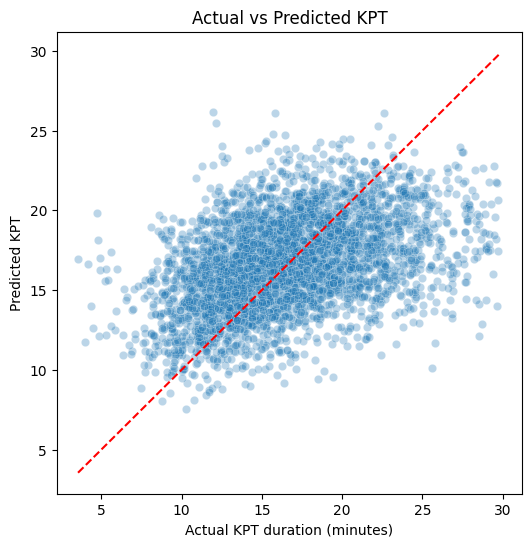

In [68]:
y_pred = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))

print("R2:", r2_score(y_test, y_pred))


plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.xlabel("Actual KPT duration (minutes)")
plt.ylabel("Predicted KPT")
plt.title("Actual vs Predicted KPT")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

## Khởi tạo MultiLabelBinarizer ##

Mục đích: Đảm bảo mã hóa món ăn nhất quán giữa huấn luyện và dự đoán.

Hành động:
Fit MultiLabelBinarizer trên danh sách món ăn từ dữ liệu gốc.

In [69]:
from sklearn.preprocessing import MultiLabelBinarizer

# Fit MultiLabelBinarizer lại từ dữ liệu train gốc
mlb = MultiLabelBinarizer()
mlb.fit(df['item_list'])  # df là DataFrame gốc bạn dùng để train mô hình

MultiLabelBinarizer()

## Dự đoán trên dữ liệu mẫu ##

Mục đích: Dự đoán KPT cho các đơn hàng mẫu từ sample_orders.csv.

Hành động:
Đọc file mẫu, tiền xử lý (thời gian, số món, tên món).
Mã hóa món ăn bằng MultiLabelBinarizer.
Dự đoán KPT bằng mô hình Random Forest.
Hiển thị kết quả: Order ID, Items in order, KPT dự đoán, KPT thực tế.

In [71]:
import pandas as pd
import numpy as np
import re

# Đọc dữ liệu sample
sample_df = pd.read_csv('/Users/chauanhkhoi/Documents/ĐẠI HỌC/HK6/PTDL_KD/DO AN/DoAn_2/TỐI ƯU RIDER WAIT TIME/sample_orders.csv')

# Parse thời gian
sample_df['Order Placed At'] = pd.to_datetime(sample_df['Order Placed At'], format="%I:%M %p, %B %d %Y", errors='coerce')
sample_df = sample_df.dropna(subset=['Order Placed At'])

# Tạo feature từ thời gian
sample_df['hour'] = sample_df['Order Placed At'].dt.hour
sample_df['weekday'] = sample_df['Order Placed At'].dt.weekday

# Hàm đếm số lượng món
def count_items(item_str):
    if pd.isna(item_str):
        return 0
    matches = re.findall(r'(\d+)x', item_str)
    if matches:
        return sum(int(m) for m in matches)
    else:
        return len(str(item_str).split(','))

# Hàm tách tên món
def extract_item_names(item_str):
    if pd.isna(item_str):
        return []
    items = [re.sub(r'^\s*\d+x\s*', '', i.strip().lower()) for i in item_str.split(',')]
    return items

# Áp dụng feature engineering
sample_df['num_items'] = sample_df['Items in order'].apply(count_items)
sample_df['item_list'] = sample_df['Items in order'].apply(extract_item_names)

# Encode món ăn giống lúc train
sample_item_features = pd.DataFrame(mlb.transform(sample_df['item_list']), columns=mlb.classes_, index=sample_df.index)

# Kết hợp với các đặc trưng số
basic_features = ['num_items', 'hour', 'weekday']
X_sample = pd.concat([sample_df[basic_features], sample_item_features], axis=1)

# Đảm bảo không thiếu cột nào
missing_cols = set(X.columns) - set(X_sample.columns)
for col in missing_cols:
    X_sample[col] = 0
X_sample = X_sample[X.columns]  # Sắp xếp đúng thứ tự cột như khi train

# Dự báo
sample_df['Predicted KPT duration (minutes)'] = rf.predict(X_sample)

# Kết quả
sample_df[['Order ID', 'Items in order', 'Predicted KPT duration (minutes)', 'KPT duration (minutes)']]

,Order ID,Items in order,Predicted KPT duration (minutes),KPT duration (minutes)
0,6168884918,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",20.790133,18.35
1,6170707559,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",16.982000,16.95
2,6169375019,1 x Bone in Peri Peri Grilled Chicken,14.645300,14.05
3,6151677434,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",20.962493,19.00
4,6167540897,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",16.789100,15.97
5,7000000001,"1 x Veg Biryani, 1 x Butter Naan",18.373700,13.50
6,7000000002,"1 x Paneer Tikka, 1 x Masala Lemonade",17.255500,17.20
7,7000000003,"1 x Chicken Kathi Roll, 1 x Coke",16.432215,15.00
8,7000000004,"1 x Chicken Biryani, 1 x Raita",16.832675,20.30
9,7000000005,"1 x Idli Sambar, 1 x Filter Coffee",19.677000,10.90


## Tối ưu hóa thời gian chờ tài xế ##
Mục đích: Đề xuất thời gian thông báo tài xế để giảm thời gian chờ.

Hành động:
- Lọc đơn hàng có Rider wait time > 7 phút.
- Dự đoán KPT cho các đơn này.
- Lấy mẫu 60 đơn ngẫu nhiên.
- Đề xuất thời điểm thông báo tài xế (KPT_pred - 5 phút).
- Tính thời gian chờ sau điều chỉnh.
- Hiển thị kết quả: Order ID, Items, Rider wait time, KPT thực tế, KPT dự đoán, Thời gian thông báo, Thời gian chờ mới.

In [80]:
import pandas as pd
import numpy as np

# Bước 1: Lọc các đơn có Rider Wait Time > 7 phút
df_long_wait = df_features[df_features['Rider wait time (minutes)'] > 7].copy()

# Bước 2: Dự đoán KPT cho các đơn này
X_long_wait = df_long_wait[basic_features + item_columns]
df_long_wait['KPT_pred'] = rf.predict(X_long_wait)

# Bước 3: Lấy ngẫu nhiên 50 dòng
df_sample = df_long_wait.sample(n=60, random_state=42).copy()

# Bước 4: Tính thời điểm báo tài xế
df_sample['Suggested_notify_time'] = df_sample['KPT_pred'] -  5 # phút trước khi món xong

# Bước 5: So sánh hiệu quả
df_sample['Actual_KPT'] = df_sample['KPT duration (minutes)']
df_sample['Thời gian chờ sau điều chỉnh'] = df_sample['Actual_KPT'] - df_sample['Suggested_notify_time'] 

# Hiển thị kết quả
df_sample_display = df_sample[[
    'Order ID', 'Items in order', 'Rider wait time (minutes)', 'Actual_KPT', 'KPT_pred',
    'Suggested_notify_time', 'Thời gian chờ sau điều chỉnh'
]]

df_sample_display.head(10)




,Order ID,Items in order,Rider wait time (minutes),Actual_KPT,KPT_pred,Suggested_notify_time,Thời gian chờ sau điều chỉnh
5343,6258921542,1 x Murgh Amritsari Garlic Bread,10.0,15.50,14.247412,9.247412,6.252588
13053,6449825966,1 x Mutton Seekh Pizza,7.8,15.48,15.734150,10.734150,4.745850
16503,6539670248,"1 x Fried Chicken Peri Peri Tender, 1 x AAC Gr...",8.4,18.45,18.107900,13.107900,5.342100
15831,6491028623,"1 x All About Chicken Pizza, 1 x Herbed Potato...",16.8,27.65,25.519200,20.519200,7.130800
13864,6432471062,"2 x Tripple Cheese Pizza, 4 x Bageecha Pizza",14.1,26.32,23.258850,18.258850,8.061150
4906,6264602155,"1 x Bone in Angara Grilled Chicken, 1 x Bone i...",12.2,24.13,22.815200,17.815200,6.314800
16375,6492220400,"1 x Jamaican Chicken Melt, 1 x Fried Chicken T...",13.7,23.30,21.810700,16.810700,6.489300
17980,6545232955,1 x Bone in Smoky Bbq Grilled Chicken,11.5,18.47,18.684470,13.684470,4.785530
583,6160765669,1 x Peri Peri Grilled Chicken Pizza,11.3,18.47,18.886982,13.886982,4.583018
16348,6503110992,"1 x Margherita Pizza, 1 x Just Pepperoni Pide",11.7,16.22,16.204400,11.204400,5.015600


## so sánh các mô hình ##
Mục đích: Xem xét sai số và R2 cho tập train và tập test



--- Radom Forest ---
MAE (Test): 4.094811711165915
R² (Train): 0.21134748635520784
R² (Test): 0.10537585120661386



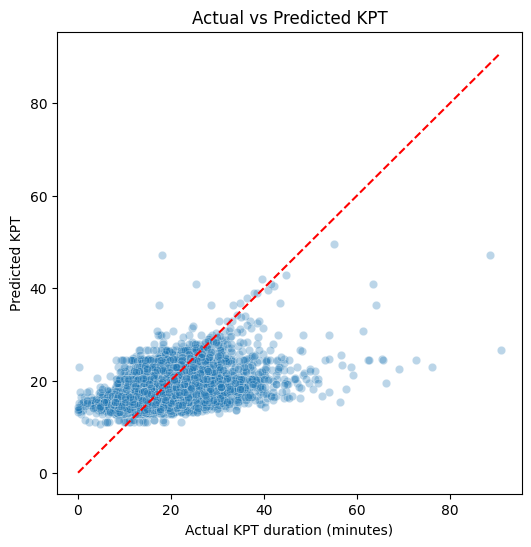

--- Linear Regression ---
MAE (Test): 4.030619665079088
R² (Train): 0.13638398920476602
R² (Test): 0.12366368648113735



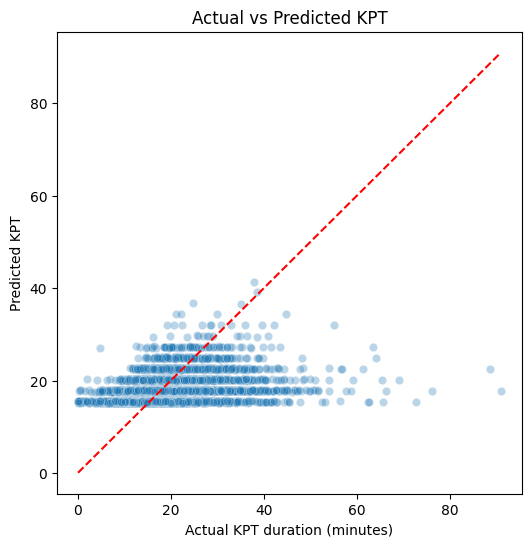

--- Gradient Boosting Regressor ---
MAE (Test): 4.028098102448426
R² (Train): 0.17039950969356754
R² (Test): 0.13358690488580982



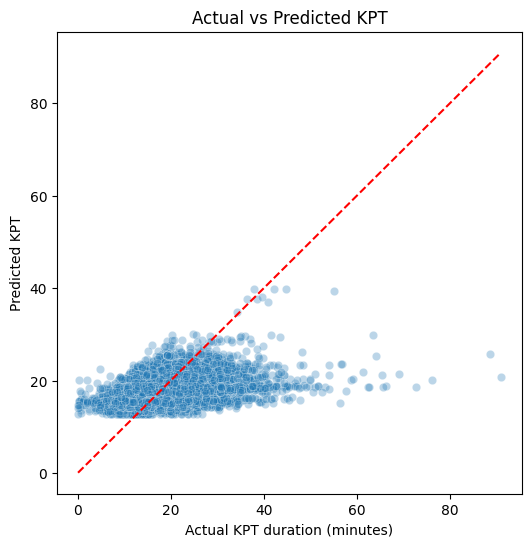

--- XGBoost Regressor ---
MAE (Test): 4.096017375494435
R² (Train): 0.21069681141887953
R² (Test): 0.10199506535435965



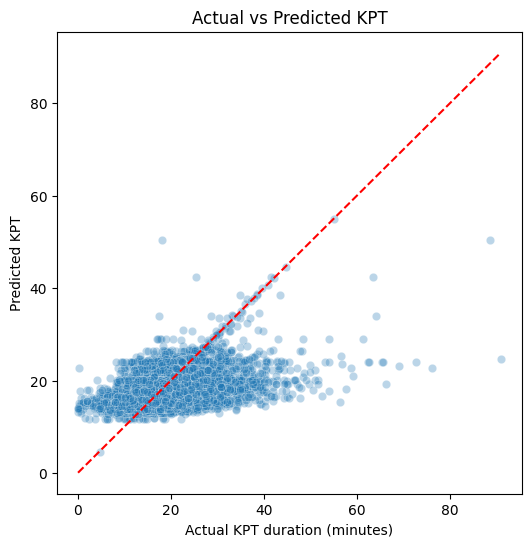

In [77]:

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb

# Chuẩn bị dữ liệu
features = ['num_items', 'hour', 'weekday']
X = df[features]
y = df['KPT duration (minutes)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print("MAE (Test):", mean_absolute_error(y_test, y_test_pred))
   
    print("R² (Train):", r2_score(y_train, y_train_pred))
    print("R² (Test):", r2_score(y_test, y_test_pred))
    print()

    plt.figure(figsize=(6,6))
    sns.scatterplot(x=y_train, y=y_train_pred, alpha=0.3)
    plt.xlabel("Actual KPT duration (minutes)")
    plt.ylabel("Predicted KPT")
    plt.title("Actual vs Predicted KPT")
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.show()

# Radom Forest
rf_model = RandomForestRegressor()
evaluate_model(rf_model, "Radom Forest")

# Linear Regression
lr_model = LinearRegression()
evaluate_model(lr_model, "Linear Regression")

# Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=42)
evaluate_model(gb_model, "Gradient Boosting Regressor")

# XGBoost
xgb_model = xgb.XGBRegressor(random_state=42, verbosity=0)
evaluate_model(xgb_model, "XGBoost Regressor")






## 📊 Nhận xét & Kết luận

### Nhận xét:
Trong quá trình so sánh 4 mô hình hồi quy gồm **Random Forest**, **Linear Regression**, **Gradient Boosting Regressor** và **XGBoost**, kết quả thu được như sau:

- **Random Forest Regressor** cho kết quả khá ổn định với R² = **0.21 trên tập huấn luyện**, và R² = **0.10 trên tập kiểm tra**. Mặc dù không phải là mô hình có R² test cao nhất, nhưng mô hình cho thấy **tính ổn định và khả năng học tốt mối quan hệ phi tuyến giữa các đặc trưng**.
- So với XGBoost – một mô hình phức tạp hơn – Random Forest cho kết quả **tương đương nhưng dễ triển khai hơn**, ít yêu cầu tuning tham số.
- So với Linear Regression, Random Forest học được **các tương tác phi tuyến giữa số lượng món, giờ đặt hàng và thứ trong tuần**, vốn không thể hiện rõ trong mô hình tuyến tính.
- Gradient Boosting có R² test cao nhất (≈ 0.134), tuy nhiên sự chênh lệch nhỏ này có thể không đáng kể khi đánh đổi với **tính dễ cài đặt, ít rủi ro overfitting và tốc độ huấn luyện ổn định** của Random Forest.

### Kết luận:
- **Random Forest Regressor là mô hình hợp lý và đáng tin cậy** để triển khai trong thực tế nhờ tính đơn giản, khả năng xử lý tốt dữ liệu ít được xử lý và khả năng giải thích các đặc trưng quan trọng (feature importance).
- Trong tương lai, có thể tiếp tục nâng cao hiệu quả của Random Forest bằng cách:
  - Bổ sung thêm các đặc trưng liên quan đến loại món ăn, thời điểm cao điểm, thông tin nhà hàng,...
  - Kết hợp với kỹ thuật **feature selection** hoặc **tối ưu tham số bằng GridSearchCV/RandomizedSearchCV** để tăng độ chính xác.
- Với dữ liệu hiện tại, Random Forest thể hiện là mô hình **cân bằng tốt giữa độ chính xác và độ ổn định**, rất phù hợp để làm baseline trong các hệ thống dự báo thời gian chuẩn bị món ăn.

---